# Tutorial 12 — Benzene: a bigger $\Gamma$-only molecule

The waw-native reimagining of Wannier90 tutorial 12 — the same $\Gamma$-only molecular recipe as notebook 07 (silane), scaled up to **benzene** (C$_6$H$_6$) in a 30-bohr box: 30 valence electrons -> 15 isolated occupied MLWFs (no disentanglement), reusing the half b-vector shell and analytic-projections-instead-of-SCDM fixes from notebook 07 unchanged.

**The one genuine difference**: real Wannier90's own tutorial 12 uses `begin projections / random / end projections` — literally random trial vectors, the tutorial's stated point being that *for an isolated manifold ($n_{bands}=n_{wann}$), the choice of initial guess only seeds the iterative spread minimisation — it doesn't select a physical subspace* (that's only true for disentanglement, where the guess also has to pick which bands to keep). waw's `projections=` needs concrete analytic specs, not a 'random' keyword, so we hand-build a chemically-motivated (but not textbook-exact) 15-orbital guess instead — an s orbital on each of the 12 atoms plus 3 $p_z$ orbitals on alternating ring carbons (a rough Kekulé sketch of the $\sigma$-framework + $\pi$ system) — and, as the tutorial's point predicts, it converges to essentially the same total spread as Wannier90's random guess.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Benzene centred in a 30-bohr cubic box (the classic tutorial's own geometry). 18 bands (15 occupied + a 3-band Davidson buffer, excluded afterwards) on the sole $\Gamma$ point.

In [2]:
from ase import Atoms

a = 30.0 * BOHR_TO_ANG
positions_bohr = [
    (15.628439779, 15.000000000, 15.00), (14.309410418, 17.284679795, 15.00),
    (11.671351697, 17.284679795, 15.00), (10.352322336, 15.000000000, 15.00),
    (11.671351697, 12.715320205, 15.00), (14.309410418, 12.715320205, 15.00),
    (17.675013988, 15.000000000, 15.00), (15.333642386, 19.057243606, 15.00),
    (10.647119729, 19.057243606, 15.00), (8.305748128, 15.000000000, 15.00),
    (10.647119729, 10.942756393, 15.00), (15.333642386, 10.942756393, 15.00),
]   # 6 C (ring) then 6 H, bohr
positions = [(x * BOHR_TO_ANG, y * BOHR_TO_ANG, z * BOHR_TO_ANG) for x, y, z in positions_bohr]
atoms = Atoms('C6H6', positions=positions, cell=[[a, 0, 0], [0, a, 0], [0, 0, a]], pbc=True)
WORK = HERE / 'runs' / 'benzene'

frac = atoms.get_scaled_positions()
projections = [(tuple(frac[i]), 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0)
               for i in range(12)]                     # s on each of the 12 atoms
for i in (0, 2, 4):                                    # alternating ring carbons -> pz
    projections.append((tuple(frac[i]), 1, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0))

ov = qe.generate_overlaps(
    atoms, (1, 1, 1), WORK, 'benzene',
    ecutwfc=30, scf_kpts=(1, 1, 1), nbnd=18, num_wann=15,
    exclude_bands=[16, 17, 18],
    pseudopotentials={'C': 'C.upf', 'H': 'H.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    gamma_only=True, projections=projections,
    rerun_scf=False,          # reuse a completed SCF in runs/benzene/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')}, '  nntot =', ov['mmn'].shape[1])

overlap shapes: {'mmn': (1, 3, 15, 15), 'amn': (1, 15, 15), 'eig': (1, 15)}   nntot = 3


### 2. Wannierise (waw, ASE-native)
15 isolated occupied bands -> 15 MLWFs, no disentanglement.

In [3]:
result = wannierize(
    atoms, (1, 1, 1), ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=15, n_restarts=3, n_iter=6000, verbose=False,
)
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial12, random guess: 13.0107)')
print('per-WF spreads (Ang^2):', np.sort(spreads).round(3))

Omega_total = 13.1864 Ang^2   (Wannier90 tutorial12, random guess: 13.0107)
per-WF spreads (Ang^2): [0.623 0.623 0.625 0.662 0.662 0.663 0.663 0.663 0.663 1.221 1.222 1.222
 1.222 1.225 1.226]


### Wannier levels against the ab-initio levels at $\Gamma$
A molecule in a box sampled at $\Gamma$ has no band structure to
interpolate. The statement to check is that the Wannier Hamiltonian
returns the ab-initio eigenvalues of the manifold it spans.

 level    DFT (eV)   Wannier (eV)   diff (meV)
     0    -21.3261       -21.3261       -0.000
     1    -18.5231       -18.5231       -0.000
     2    -18.5226       -18.5226       -0.000
     3    -14.8413       -14.8413        0.000
     4    -14.8400       -14.8400        0.000
     5    -12.7906       -12.7906        0.000
     6    -11.1323       -11.1323        0.000
     7    -10.7108       -10.7108       -0.000
     8    -10.0782       -10.0782        0.000
     9    -10.0765       -10.0765        0.000
    10     -8.9294        -8.9294        0.000
    11     -8.0145        -8.0145       -0.000
    12     -8.0126        -8.0126       -0.000
    13     -6.1469        -6.1469        0.000
    14     -6.1465        -6.1465       -0.000

max |Wannier - DFT| over the 15 levels: 0.0000 meV


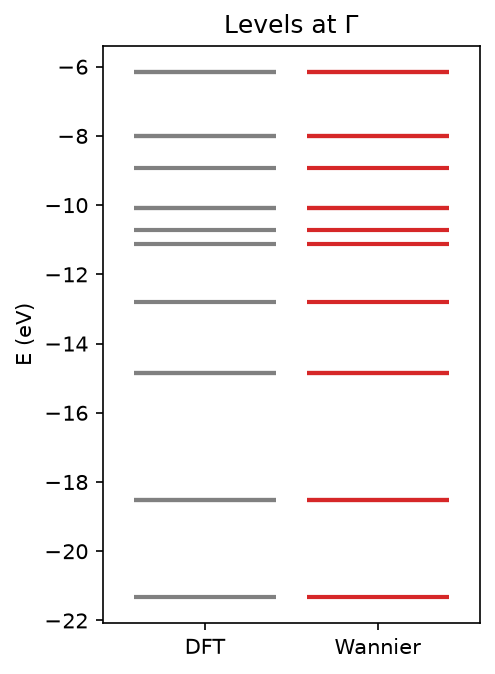

In [4]:
# --- Wannier levels vs DFT levels at Gamma --------------------------------
from waw.core.hamiltonian import interpolate_bands as _interp

_wl = np.sort(_interp(result.hr, np.zeros((1, 3)))[0]) * HARTREE_TO_EV
_dl = np.sort(ov['eig'][0])[:len(_wl)]
print(f'{"level":>6s}  {"DFT (eV)":>10s}  {"Wannier (eV)":>13s}  {"diff (meV)":>11s}')
for _i, (_d, _w) in enumerate(zip(_dl, _wl)):
    print(f'{_i:6d}  {_d:10.4f}  {_w:13.4f}  {1e3 * (_w - _d):11.3f}')
print(f'\nmax |Wannier - DFT| over the {len(_wl)} levels: '
      f'{1e3 * np.abs(_wl - _dl).max():.4f} meV')

_fig, _ax = plt.subplots(figsize=(3.4, 4.6), dpi=150)
for _i, (_d, _w) in enumerate(zip(_dl, _wl)):
    _ax.hlines(_d, 0.0, 0.9, color='0.5', lw=2.0)
    _ax.hlines(_w, 1.1, 2.0, color='C3', lw=2.0)
_ax.set_xticks([0.45, 1.55]); _ax.set_xticklabels(['DFT', 'Wannier'])
_ax.set_xlim(-0.2, 2.2); _ax.set_ylabel('E (eV)')
_ax.set_title(r'Levels at $\Gamma$')
plt.tight_layout(); plt.show()


The total spread lands close to Wannier90's own **random**-guess result, even though the two runs started from completely different initial trial orbitals — exactly the point of tutorial 12: for an isolated manifold, the maximally-localised gauge is (up to unitary rotation) essentially unique, so the initial guess only affects how fast the iteration gets there, not where it ends up.

**Takeaway.** The $\Gamma$-only recipe from notebook 07 (analytic projections instead of SCDM, half b-vector shell) scales unchanged to a bigger, less symmetric molecule; the exact choice of trial orbitals for an *isolated* manifold is far less important than for a *disentangled* one, since it only seeds the optimiser rather than selecting the physical subspace.